## Imports and Data Loading

In [109]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet


from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from data_cleaning import load_clean_data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [110]:
# load data
path = "../data/final_train.csv"
# df = load_clean_data(path)
df = pd.read_csv(path)

In [111]:
df.shape

(5502, 26)

## Feature Importance using Random Forest Regressor

In [112]:
# drop target columns and columns that will likely lead to overfitting if included
drop_cols = ["log_abundance", "cyanobacteria_abundance", "latitude", "longitude", "satellite_date", "nutrients_date"]
X = df.drop(columns=drop_cols)
y = df["log_abundance"]

In [113]:
X["caml_sample_date"] = pd.to_datetime(X["caml_sample_date"])
X['doy'] = X['caml_sample_date'].dt.dayofyear
X = X.drop(columns = "caml_sample_date")

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [115]:
# create random forest model
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features=None)
rf.fit(X_train, y_train)
print("R Squared:", rf.score(X_test, y_test))

R Squared: 0.7187790729037635


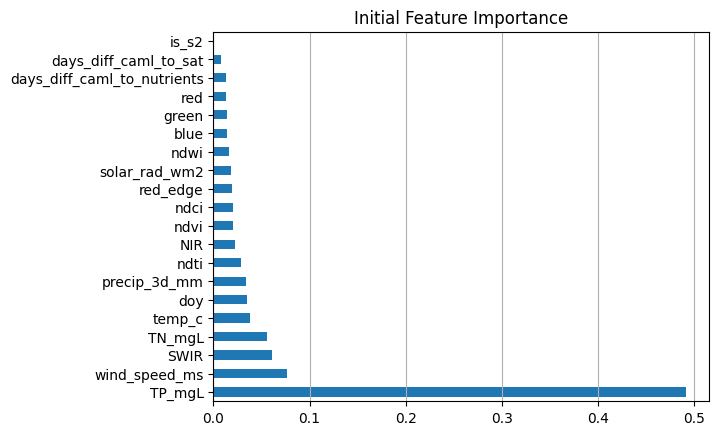

In [116]:
# plot feature importances 
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Initial Feature Importance")
plt.grid(which="both", axis="x")
plt.show()

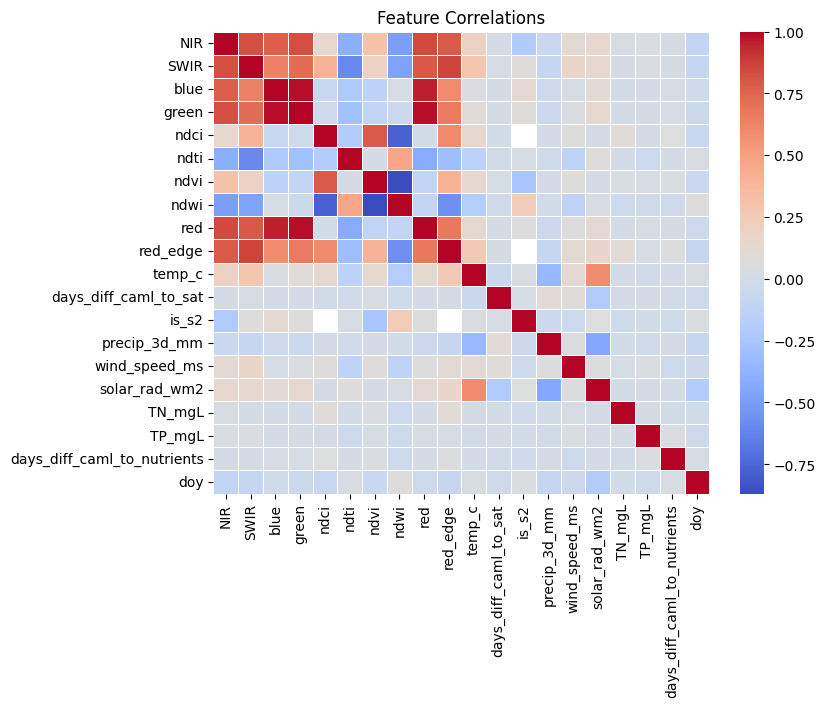

In [117]:
# get feature correlations
matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlations")
plt.show()

In [118]:
drop = ["days_diff_caml_to_nutrients", "days_diff_caml_to_sat", "NIR", "ndwi", "is_s2"]
X = X.drop(columns=drop)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features=None)
rf.fit(X_train, y_train)
print("R Squared:", rf.score(X_test, y_test))

R Squared: 0.7201056840609419
